# Animation Elements for Video 1 of Electric Field Series
## Created by: Antonio Cascio, Blake Head
## Date: 2023-10-02
### Description: This notebook generates individual animation elements for the first video in the Electric Field series.


# Load in Libraries

In [1]:
from manim import *
import manim_physics as mp
import numpy as np

# Define Global Variables to be used throughout video

Here, we define a few objects that are used throughout the video. The functions here are:

- wind_field
    - Creates a vector field that represents the wind field created by the fan
- create_fan
    - Defines and saves parameters to create the fan object.
- create_kite
    - Defines and saves parameters to create the kite object.


In [11]:
def wind_field(point):
    x, y, _ = point
    x -= 1  # Fan origin in x-axis
    y -= 0   # Fan origin in y-axis

    # Compute the magnitude and direction of airflow
    distance = np.sqrt(x**2 + y**2)
    if distance == 0:
        return np.array([0, 0, 0])

    # Magnitude decreases with distance from the fan
    magnitude = 1 / (1 + 0.2 * distance)

    # Flow primarily in x-direction with some spreading in y-direction
    direction = np.array([-1, y / (distance + 0.1), 0])

    # Normalize and scale with magnitude
    return magnitude * direction

def create_fan():
#Create the Fan VGroup
    fan_center = Dot(radius=0.15, color=WHITE)
    fan_body = Circle(radius = 1.2, color=WHITE)
    fan_base = Ellipse(width = 1.8, height= 0.2, color=WHITE).shift(DOWN*3)
    fan_stand = Line(start=fan_body.get_bottom(), end=fan_base.get_top(), color=WHITE)
    
    # Create the fan blades
    blade1 = Polygon(
        ORIGIN, 
        [0.3, 0.3, 0], 
        [0.8, 0, 0], 
        [-0.3, -0.3, 0],
        color=WHITE,
        fill_opacity=0.6
    ).shift(UP * 0.6).rotate(PI / 6)

    # Clone blades and position them
    blade2 = blade1.copy().rotate(PI * 2 / 3, about_point=fan_center.get_center())
    blade3 = blade1.copy().rotate(-PI * 2 / 3, about_point=fan_center.get_center())

    # Group the blades and center
    fan_blades = VGroup(blade1, blade2, blade3)
    fan = VGroup(fan_center, fan_blades, fan_body, fan_base, fan_stand).shift(RIGHT*3)
    
    return fan, fan_blades, fan_body, fan_base, fan_stand, fan_center

def create_kite():
        #Create the kite
    kite_top = Polygon( [-0.6, 0, 0], 
                    [-1, 0.5, 0], 
                    [-0.6, 1, 0], 
                    [-0.2, 0.5, 0], 
                    color=WHITE, 
                    fill_opacity=0.6
                    ).scale(2).shift(LEFT*3)
            
    # Create the string 
    kite_string = VMobject() 
    kite_string.set_points_as_corners( [[-0.6, -1, 0], 
                                        [-0.7, -1.1, 0], 
                                        [-0.5, -1.2, 0], 
                                        [-0.6, -1.3, 0], 
                                        [-0.5, -1.4, 0], 
                                        [-0.6, -1.5, 0]] 
                                    ).scale(3).shift(LEFT*3) 
    
    kite = VGroup(kite_top, kite_string)

    return kite, kite_top, kite_string

# Testing Area

Add objects here to test things if you need to.

The manim module is not an IPython extension.


Manim Community v0.18.1

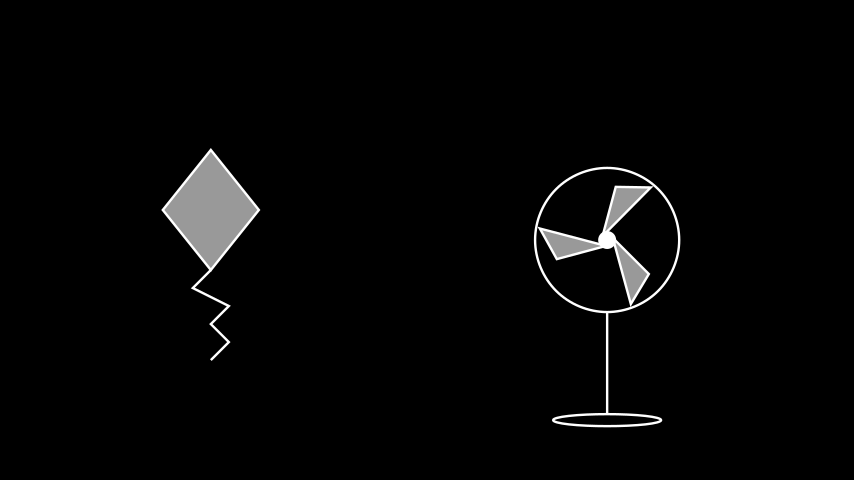

In [42]:
class Test(Scene):
    def construct(self):
        fan = create_fan()[0]
        kite=create_kite()

        self.add(fan, kite)

# Load the manim extension
%load_ext manim 

# Render the main scene
%manim -ql -v WARNING Test

# Scene 1: Intro Picture

First we will show the viewer a scene with three point charges, electric force vectors illustrated, as well as Coulomb's law.
This first scene will be to motivate the idea behind electric fields: How do charges know other charges are there?

In [ ]:
class IntroScene(Scene):
    def construct(self):
        # The first part of the video is showcasing the 3 charges

        # Create the charges and set the position
        charge1 = mp.Charge(magnitude=1, point=np.array([-4, -1, 0]))
        charge2 = mp.Charge(magnitude=1, point=np.array([4, 1, 0]))
        charge3 = mp.Charge(magnitude=-1, point=np.array([0, 3, 0]))

        # Add to the scene
        self.add(charge1, charge2, charge3)

        # Create the lines that connect the charges
        line1 = Line(start = charge1.get_center(), end=charge3.get_center())
        line2 = Line(start = charge1.get_center(), end=charge2.get_center())
        line3 = Line(start = charge2.get_center(), end=charge3.get_center())

        # Add to the scene
        self.add(line1, line2, line3)

        # Create the Force arrows
        # Charge 1 arrows
        q1_f1_arrow = LabeledArrow(MathTex("\\vec{F_1}"), start=charge1.get_center(), end=charge3.get_center(), color=GREEN)
        
        # Reverse the direction of q1_f2_arrow while keeping the same magnitude
        q1_f2_start = charge1.get_center()
        q1_f2_end = charge2.get_center()
        q1_f2_magnitude = q1_f2_end - q1_f2_start
        reversed_q1_f2_end = q1_f2_start - q1_f2_magnitude
        q1_f2_arrow = LabeledArrow(MathTex("\\vec{F_2}"), start=charge1.get_center(), end=reversed_q1_f2_end, color=GREEN)

        q1_f1_arrow.scale(0.25, about_point=q1_f1_arrow.get_start())
        q1_f2_arrow.scale(0.25, about_point=q1_f2_arrow.get_start())


        # Charge 2 arrows
        q2_f3_arrow = LabeledArrow(MathTex("\\vec{F_3}"), start=charge2.get_center(), end=charge3.get_center(), color=GREEN)
        
        # Reverse the direction of q2_f2_arrow while keeping the same magnitude
        q2_f2_start = charge2.get_center()
        q2_f2_end = charge1.get_center()
        q2_f2_magnitude = q2_f2_end - q2_f2_start
        reversed_q2_f2_end = q2_f2_start - q2_f2_magnitude
        q2_f2_arrow = LabeledArrow(MathTex("\\vec{F_2}"), start=charge2.get_center(), end=reversed_q2_f2_end, color=GREEN)

        q2_f3_arrow.scale(0.25, about_point=q2_f3_arrow.get_start())
        q2_f2_arrow.scale(0.25, about_point=q2_f2_arrow.get_start())

        # Charge 3 arrows
        q3_f1_arrow = LabeledArrow(MathTex("\\vec{F_1}"), start=charge3.get_center(), end=charge1.get_center(), color=GREEN)
        q3_f3_arrow = LabeledArrow(MathTex("\\vec{F_3}"), start=charge3.get_center(), end=charge2.get_center(), color=GREEN)

        q3_f1_arrow.scale(0.25, about_point=q3_f1_arrow.get_start())
        q3_f3_arrow.scale(0.25, about_point=q3_f3_arrow.get_start())

        # Add the arrows to the Scene
        self.add(q1_f1_arrow, q1_f2_arrow, q2_f2_arrow, q2_f3_arrow, q3_f1_arrow, q3_f3_arrow)

        # Equation time
        equation = MathTex(
            "\\vec{F_c}", "=", "k_c", "{q_1", "q_2", "\\over", "r^2}", "\\hat{r}"
        )
        equation.move_to(DOWN*1.5)

        #Add the equation
        self.add(equation)

        #Run the scene for as long as desired
        self.wait(2.5)

        #Prepare the next scene of the charges floating in space
        self.play(FadeOut(line1,line2,line3
                          ,equation))

        #Scene runtime
        self.wait(2.5)

        #Remove the charges for the next scene and add the kite and fan
        self.play(FadeOut(charge1, charge2, charge3,
                          q1_f1_arrow, q1_f2_arrow,
                          q2_f2_arrow, q2_f3_arrow,
                          q3_f1_arrow, q3_f3_arrow))
        
# Load the manim extension
%load_ext manim 

# Render the main scene
%manim -ql -v WARNING IntroScene

The manim module is not an IPython extension.


Manim Community v0.18.1

# Scene 2: Fan and Kite (pt 1)

In this scene, we add a fan and kite to the scene.  This is a multi-part scene, and is comprised of many moving elements. The primary objects throughout are as follows:

- The fan body
- The rotating fan blades
- The kite
- Foce vector on kite.
- The wind field lines (defined in function above)

In this part 1, the fan and kite are stationary, and the blades are NOT rotating.

Note the first two lines: These are calling our 'create' functions definied up at the top of this file.  
This allows the individual code blocks to be much more compact.  The bracketed numbers says which element of the definition output to assign to our variable. Those elements are:

- [0] = fan
- [1] = fan_blades
- [2] = fan_body
- [3] = fan_base
- [4] = fan_stand
- [5] = fan_center

In [61]:
class FanScene1(Scene):
        def construct(self):
            fan = create_fan()[0]
            kite = create_kite()[0]

            #Add the Fan and Kite to the scene
            self.play(FadeIn(fan, kite))

            #Running the scene for set time
            self.wait(2)
    
    # Load the manim extension
%load_ext manim 

# Render the main scene
%manim -ql -v WARNING FanScene1

The manim module is not an IPython extension.


Manim Community v0.18.1

# Scene 2: Fan and Kite (Slow Wind Field Speed)

Here, we will have the fan "turn on".  The blades will rotate, and we will add in the Wind Field and Force Vector on the kite. 

In this block as well, we call the function "Wind Field" to define a wind field with a slow speed:

- stream_lines_slow

Ideally, the two functions (get_vector and update_vector) shouldn't need to be touched.


In [18]:
class FanScene2(Scene):
    def construct(self):

        # Add in objects present at end of previous scene
        fan = create_fan()[0]
        fan_blades = create_fan()[1]
        fan_body = create_fan()[2]
        fan_base = create_fan()[3]
        fan_stand = create_fan()[4]
        fan_center = create_fan()[5]


        kite_top = create_kite()[1]
        kite_string = create_kite()[2]
        self.add(fan_body, fan_stand, fan_base, fan_center, fan_blades)
        kite = VGroup(kite_top, kite_string)
        self.add(kite)
        # Store the initial position of the kite
        kiteIP = kite.get_center()

    # Next part of the scene is to add the streamlines/wind

    # Create the corner covers (hard coded)
    # There are used to cover the top and bottom right corners to make the field look more correct.

        corner_cover1 = Circle(radius=5, color=BLACK, fill_opacity=1).shift(UP*5+RIGHT*7)
        corner_cover2 = Circle(radius=5, color=BLACK, fill_opacity=1).shift(UP*-5+RIGHT*7)

        
    # Create streamlines from the vector field
    # I define 3 different streamlines that will represent a slow/medium/fast fan speed.
    # I also slightly adjust the virtual_time variable for each, making it a bit larger for faster fields.

    # If things in the animation look a little bad, try changing the 'virtual time' paramenter by a couple.

        stream_lines_slow = StreamLines(
                wind_field,
                stroke_width=2, # Make the lines wider
                max_anchors_per_line=30,
                virtual_time=2 # 
            )

        # This line adds an updater to the fan blades so that they will continue to rotate
        # throughout the animations.  
        # Multiplying the angle by 'speed' allows us to adjust the speed of the fan below.
        fan_blades.add_updater(lambda mob, dt: mob.rotate(angle=speed*dt*PI, 
                                                            about_point=fan_center.get_center())
                                )

    # Here we create the force vector that will illustrate the wind force.
    # Set vector parameters here:
        vec_color = PURE_GREEN
        vec_magnitude = 5
    # Function to compute vector direction and inverse distance magnitude
        def get_vector():
            direction = kite_top.get_center() - fan.get_center()  # Direction from red to blue
            distance = np.linalg.norm(direction)  # Compute distance
                
            if distance == 0:  # Avoid division by zero
                return Vector([0, 0, 0]).set_color(vec_color)

            unit_direction = direction / distance  # Normalize direction
            magnitude = vec_magnitude / distance  # Inverse proportionality (scaled factor for visibility)

            start_point = kite_top.get_center()  # Start at the kite
            end_point = start_point + unit_direction * magnitude  # End point based on direction and magnitude

            return Vector(end_point - start_point).set_color(vec_color).put_start_and_end_on(start_point, end_point)

        # Create initial vector
        vec = get_vector()
            
        # Updater to dynamically adjust vector direction and magnitude
        def update_vector(mob):
            direction = kite_top.get_center() - fan.get_center()  # Direction from fan to kite
            distance = np.linalg.norm(direction)  # Compute distance

            if distance == 0:  # Avoid division by zero
                mob.put_start_and_end_on(kite_top.get_center(), kite_top.get_center())
                return

            unit_direction = direction / distance  # Normalize direction
            magnitude = vec_magnitude / distance  # Inverse proportionality (scaled factor for visibility)

            start_point = kite_top.get_center()  # Start at the kite
            end_point = start_point + unit_direction * magnitude  # End point based on direction and magnitude

            mob.put_start_and_end_on(start_point, end_point)  # Update vector's start and end points

        vec.add_updater(update_vector)

    # Start animations

        # Medium Wind Field

        speed = 0.5 # Change this to make the fan spin faster or slower
        vec_magnitude = 2 # Change this to update the base size of the force vector to account for wind strength.

        # Add in all scene elements
        self.add(stream_lines_slow, corner_cover1, corner_cover2)
        self.add(fan_base,fan_stand)
        self.add(vec)
        # Start the StreamLines animation bit
        # Flow speed determines how quickly the stream lines will move
        stream_lines_slow.start_animation(warm_up=False, flow_speed=.5)
        
        # Wait a moment until moving on
        self.wait(3)

        # Move the kite around
        self.play(kite.animate.move_to(RIGHT*2+DOWN*1), run_time=3)
        self.wait(2)
        self.play(kite.animate.move_to(LEFT*3+UP*0.5), run_time = 3)
        self.wait(2)
        self.play(kite.animate.move_to(kiteIP), run_time = 3)
        self.wait(2)

    # Load the manim extension
%load_ext manim 

# Render the main scene
%manim -ql -v WARNING FanScene2

The manim module is not an IPython extension.


Manim Community v0.18.1

# Scene 3: Fan and Kite (Medium Wind Field)

Same as above, we use the Wind_Field function to generate a faster moving wind field.

In [20]:
class FanScene3(Scene):
    def construct(self):

        # Add in objects present at end of previous scene
        fan = create_fan()[0]
        fan_blades = create_fan()[1]
        fan_body = create_fan()[2]
        fan_base = create_fan()[3]
        fan_stand = create_fan()[4]
        fan_center = create_fan()[5]


        kite_top = create_kite()[1]
        kite_string = create_kite()[2]
        self.add(fan_body, fan_stand, fan_base, fan_center, fan_blades)
        kite = VGroup(kite_top, kite_string)
        self.add(kite)
        # Store the initial position of the kite
        kiteIP = kite.get_center()

    # Next part of the scene is to add the streamlines/wind

    # Create the corner covers (hard coded)
    # There are used to cover the top and bottom right corners to make the field look more correct.

        corner_cover1 = Circle(radius=5, color=BLACK, fill_opacity=1).shift(UP*5+RIGHT*7)
        corner_cover2 = Circle(radius=5, color=BLACK, fill_opacity=1).shift(UP*-5+RIGHT*7)

        
    # Create streamlines from the vector field
    # I define 3 different streamlines that will represent a slow/medium/fast fan speed.
    # I also slightly adjust the virtual_time variable for each, making it a bit larger for faster fields.

    # If things in the animation look a little bad, try changing the 'virtual time' paramenter by a couple.

        stream_lines_med = StreamLines(
                wind_field,
                stroke_width=2, # Make the lines wider
                max_anchors_per_line=30,
                virtual_time=8 # 
            )

        # This line adds an updater to the fan blades so that they will continue to rotate
        # throughout the animations.  
        # Multiplying the angle by 'speed' allows us to adjust the speed of the fan below.
        fan_blades.add_updater(lambda mob, dt: mob.rotate(angle=speed*dt*PI, 
                                                            about_point=fan_center.get_center())
                                )

    # Here we create the force vector that will illustrate the wind force.
    # Set vector parameters here:
        vec_color = PURE_GREEN
        vec_magnitude = 5
    # Function to compute vector direction and inverse distance magnitude
        def get_vector():
            direction = kite_top.get_center() - fan.get_center()  # Direction from red to blue
            distance = np.linalg.norm(direction)  # Compute distance
                
            if distance == 0:  # Avoid division by zero
                return Vector([0, 0, 0]).set_color(vec_color)

            unit_direction = direction / distance  # Normalize direction
            magnitude = vec_magnitude / distance  # Inverse proportionality (scaled factor for visibility)

            start_point = kite_top.get_center()  # Start at the kite
            end_point = start_point + unit_direction * magnitude  # End point based on direction and magnitude

            return Vector(end_point - start_point).set_color(vec_color).put_start_and_end_on(start_point, end_point)

        # Create initial vector
        vec = get_vector()
            
        # Updater to dynamically adjust vector direction and magnitude
        def update_vector(mob):
            direction = kite_top.get_center() - fan.get_center()  # Direction from fan to kite
            distance = np.linalg.norm(direction)  # Compute distance

            if distance == 0:  # Avoid division by zero
                mob.put_start_and_end_on(kite_top.get_center(), kite_top.get_center())
                return

            unit_direction = direction / distance  # Normalize direction
            magnitude = vec_magnitude / distance  # Inverse proportionality (scaled factor for visibility)

            start_point = kite_top.get_center()  # Start at the kite
            end_point = start_point + unit_direction * magnitude  # End point based on direction and magnitude

            mob.put_start_and_end_on(start_point, end_point)  # Update vector's start and end points

        vec.add_updater(update_vector)

    # Start animations

        # Medium Wind Field

        speed = 1 # Change this to make the fan spin faster or slower
        vec_magnitude = 5 # Change this to update the base size of the force vector to account for wind strength.

        # Add in all scene elements
        self.add(stream_lines_med, corner_cover1, corner_cover2)
        self.add(fan_base,fan_stand)
        self.add(vec)
        # Start the StreamLines animation bit
        # Flow speed determines how quickly the stream lines will move
        stream_lines_med.start_animation(warm_up=False, flow_speed=1.5)
        
        # Wait a moment until moving on
        self.wait(3)

        # Move the kite around
        self.play(kite.animate.move_to(RIGHT*2+DOWN*1), run_time=3)
        self.wait(2)
        self.play(kite.animate.move_to(LEFT*3+UP*0.5), run_time = 3)
        self.wait(2)
        self.play(kite.animate.move_to(kiteIP), run_time = 3)
        self.wait(2)

    # Load the manim extension
%load_ext manim 

# Render the main scene
%manim -ql -v WARNING FanScene3

The manim module is not an IPython extension.


Manim Community v0.18.1

# Scene 4: Fan and Kite (Fast Wind Field)

Last one, now the fastest field